
# 5d. Biodiversity, land use & food systems

This notebook continues the Chapter 5 (Impact Investing) biodiversity case
study, translating the land-use / food-system / forestry scripts
`chap5_biodiversity8a.m` through `chap5_biodiversity17.m`, `chap5_biodiversity30a.m`
through `chap5_biodiversity30e.m`, and `chap5_biodiversity31.m` from the MATLAB
`hfs-archive` source.

Topics covered, in order:

1. Bee colony stocks (FAOSTAT) — regional stacked bars and growth tables
2. Crop production, area & yield (FAOSTAT) — concentration and area-trend charts
3. Livestock production and agricultural inputs (fertilizer/pesticide use)
4. Food balance (energy/protein/fat supply) — region and country level
5. Agricultural trade openness (FAO and OECD-FAO Outlook)
6. World maize/cereal area, yield and production
7. Ecological footprint vs. biocapacity by region
8. Food security indicators (world, country, region)
9. Global forest area, primary forest, deforestation/afforestation (FAO FRA)
10. Global thermoplastic production

All data is read directly from the FAOSTAT / OECD-FAO / Global Footprint
Network / FAO-FRA / plastics-industry extracts shipped with the book's data
archive (`data/chap5_*.xlsx`), via `pandas.read_excel` — no data is
hand-entered. Where the MATLAB source built its own `xlsread` pivot logic
(long "code/item/year/value" tables reshaped into wide arrays), the pivot is
reproduced here with `pandas.pivot_table`/`groupby`, matching the source's
column selections index-for-index.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR = "../../data"

# House palette (matches the MATLAB init_color.m constants used throughout
# the series).
color_blue    = "#1f77b4"
color_red     = "#d62728"
color_green   = "#2ca02c"
color_violet  = "#9467bd"
color_teal    = "#17becf"
color_orange  = "#ff7f0e"
color_black   = "#000000"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = False



## 1. Bee colony stocks

Source: `chap5_biodiversity8a/8b/8c.m`, data `chap5_faostat_bees.xlsx`
(FAOSTAT "Live Animals" / bee colony stocks, 1961-2022).


max abs(continents - World): 1.0


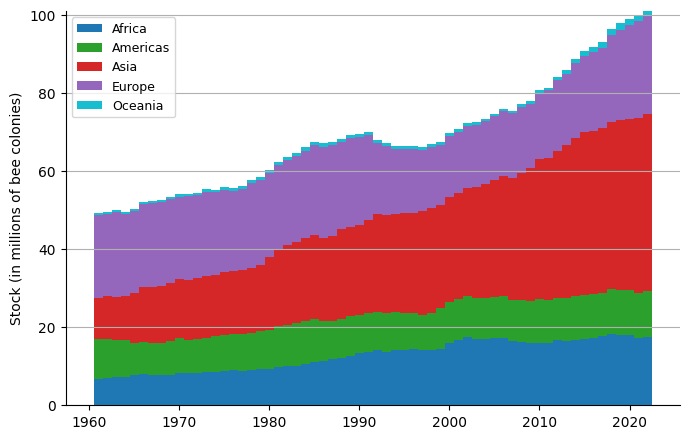

In [2]:

bees = pd.read_excel(f"{DATA_DIR}/chap5_faostat_bees.xlsx")
bees.columns = ["Area", "Year", "Value"]

area_5 = ["Africa", "Americas", "Asia", "Europe", "Oceania"]
wide = bees.pivot_table(index="Year", columns="Area", values="Value")

# Sanity check: continents should sum (approximately) to the World total,
# exactly as the source script's own `disp(max(abs(s)))` check does.
check = wide[area_5].sum(axis=1) - wide["World"]
print("max abs(continents - World):", check.abs().max())

stock = wide[area_5] / 1e6
years = stock.index.values

fig, ax = plt.subplots(figsize=(7, 4.5))
bottom = np.zeros(len(years))
colors5 = [color_blue, color_green, color_red, color_violet, color_teal]
for name, c in zip(area_5, colors5):
    ax.bar(years, stock[name].values, bottom=bottom, color=c, width=1.0, label=name)
    bottom += stock[name].values

ax.set_ylabel("Stock (in millions of bee colonies)")
ax.set_ylim(0, 101)
ax.set_yticks(range(0, 101, 20))
ax.grid(axis="y")
ax.legend(loc="upper left", fontsize=9)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


In [3]:

# 8b: regional growth table across sub-regions, selected years
area_14 = ["Europe", "Western Europe", "Northern Europe", "Eastern Europe",
           "Southern Europe", "Americas", "Northern America", "Central America",
           "Caribbean", "South America", "Africa", "Asia", "Oceania", "World"]
wide14 = bees.pivot_table(index="Year", columns="Area", values="Value") / 1e6

selected_years = [1961, 1980, 2000, 2022]
tbl = wide14.loc[selected_years, area_14].T
tbl["growth_1961_2022 (%)"] = 100 * (tbl[2022] / tbl[1961] - 1)
tbl["growth_2000_2022 (%)"] = 100 * (tbl[2022] / tbl[2000] - 1)
tbl.round(2)


Year,1961,1980,2000,2022,growth_1961_2022 (%),growth_2000_2022 (%)
Area,,,,,,
Europe,21.10,21.42,15.55,25.12,19.09,61.56
Western Europe,3.76,3.35,2.45,3.55,-5.53,45.27
Northern Europe,0.44,0.40,0.27,0.64,45.62,138.26
Eastern Europe,14.02,13.71,7.36,10.66,-23.96,44.82
Southern Europe,2.87,3.95,5.47,10.27,257.32,87.57
Americas,10.02,10.03,10.62,11.71,16.89,10.23
Northern America,5.85,4.75,3.22,3.40,-41.93,5.46
Central America,2.26,2.80,2.19,2.68,18.52,22.34
Caribbean,0.23,0.32,0.28,0.40,72.52,45.77


In [4]:

# 8c: share of 2022 stock relative to 1961, by region
area_6 = ["Europe", "Americas", "Africa", "Asia", "Oceania", "World"]
share = 100 * wide14.loc[2022, area_6] / wide14.loc[1961, area_6]
share.round(1).to_frame("2022 stock, as % of 1961")


,"2022 stock, as % of 1961"
Area,
Europe,119.1
Americas,116.9
Africa,255.1
Asia,423.6
Oceania,268.7
World,205.4



## 2. Crop production, area, yield & inputs

Source: `chap5_biodiversity9a.m` – `9e.m`. Data: FAOSTAT crop area / yield /
production tables (`Group` 1 = individual primary crops, `Group` 2 = FAO's
own commodity aggregates), plus the fertilizer/pesticide/insecticide
input tables and the livestock production table.


In [5]:

crop_area = pd.read_excel(f"{DATA_DIR}/chap5_faostat_crop_area.xlsx")
crop_area.columns = ["Code", "Item", "Year", "Value"]
crop_yield = pd.read_excel(f"{DATA_DIR}/chap5_faostat_crop_yield.xlsx")
crop_yield.columns = ["Code", "Item", "Year", "Value"]
crop_prod = pd.read_excel(f"{DATA_DIR}/chap5_faostat_crop_production.xlsx")
crop_prod.columns = ["Code", "Item", "Year", "Value", "Group"]

group_of = crop_prod[["Code", "Group"]].drop_duplicates().set_index("Code")["Group"]

def pivot_metric(df):
    return df.pivot_table(index="Code", columns="Year", values="Value")

area_w = pivot_metric(crop_area)
yield_w = pivot_metric(crop_yield)
prod_w = pivot_metric(crop_prod)

selected_year = [1961, 1980, 2000, 2020, 2022]
code_names = crop_prod[["Code", "Item"]].drop_duplicates().set_index("Code")["Item"]


In [6]:

# --- Total primary crops (Group == 1) ---
g1_codes = group_of[group_of == 1].index
x = prod_w.reindex(index=g1_codes, columns=selected_year)
w = area_w.reindex(index=g1_codes, columns=selected_year)
y = yield_w.reindex(index=g1_codes, columns=selected_year)

total_production = x.fillna(0).sum()
total_area = w.fillna(0).sum()
total_yield = (w * y).sum() / w.sum()   # area-weighted average yield per year

# --- FAO commodity aggregates (Group == 2), combined per the source script ---
g2_codes = group_of[group_of == 2].index
p2 = prod_w.reindex(index=g2_codes, columns=selected_year)
a2 = area_w.reindex(index=g2_codes, columns=selected_year)
y2 = yield_w.reindex(index=g2_codes, columns=selected_year)
g2_items = code_names.reindex(g2_codes).tolist()
print(g2_items)


['Cereals, primary', 'Citrus Fruit, Total', 'Fibre Crops, Fibre Equivalent', 'Fruit Primary', 'Oilcrops, Cake Equivalent', 'Oilcrops, Oil Equivalent', 'Pulses, Total', 'Roots and Tubers, Total', 'Sugar Crops Primary', 'Treenuts, Total', 'Vegetables Primary']


In [7]:

# Row order within the Group==2 sub-table follows the source's own
# `data1(1,:)`, `data1(2,:)+data1(4,:)`, ... row references.
def row(df, i):
    return df.iloc[i - 1]

commodity_def = {
    "Cereals":                    [1],
    "Fruit":                      [2, 4],
    "Oil crops":                  [5, 6],
    "Pulses, Roots and Tubers":   [7, 8],
    "Sugar crops":                [9],
    "Vegetables":                 [11],
}

commodity_production, commodity_area, commodity_yield = {}, {}, {}
for name, idxs in commodity_def.items():
    prod_sum = sum(row(p2, i) for i in idxs)
    area_sum = sum(row(a2, i) for i in idxs)
    commodity_production[name] = prod_sum
    commodity_area[name] = area_sum
    commodity_yield[name] = (sum(row(a2, i) * row(y2, i) for i in idxs)) / area_sum

commodity_production = pd.DataFrame(commodity_production).T
commodity_area = pd.DataFrame(commodity_area).T
other_production = total_production - commodity_production.sum()
other_area = total_area - commodity_area.sum()
commodity_production.loc["Other"] = other_production
commodity_yield = pd.DataFrame(commodity_yield).T
commodity_yield.loc["Other"] = other_production / other_area


In [8]:

# --- Top-20 individual crops by 2022 production (Group == 1) ---
x_filled = x.fillna(0)
top20_codes = x_filled[2022].sort_values(ascending=False).index[:20]

result_production = pd.concat(
    [total_production.to_frame("Primary crops").T, commodity_production, x.loc[top20_codes]]
) / 1e9
result_yield = pd.concat(
    [total_yield.to_frame("Primary crops").T, commodity_yield, y.loc[top20_codes]]
) / 1e3
result_production.index = ["Primary crops", *commodity_production.index, *code_names.reindex(top20_codes)]
result_yield.index = result_production.index

breakdown_1961 = 100 * result_production[1961] / result_production[1961].iloc[0]
breakdown_2022 = 100 * result_production[2022] / result_production[2022].iloc[0]
# Cumulative share is only meaningful across the 7 aggregate rows
# (total + 6 commodity groups), matching the source's own convention.
cum_1961 = breakdown_1961.copy(); cum_1961.iloc[1:8] = breakdown_1961.iloc[1:8].cumsum()
cum_2022 = breakdown_2022.copy(); cum_2022.iloc[1:8] = breakdown_2022.iloc[1:8].cumsum()

crop_table = pd.DataFrame({
    "Production 1961 (bn t)": result_production[1961],
    "Production 2022 (bn t)": result_production[2022],
    "Share of total, 1961 (%)": breakdown_1961,
    "Cumulative share, 1961 (%)": cum_1961,
    "Share of total, 2022 (%)": breakdown_2022,
    "Cumulative share, 2022 (%)": cum_2022,
    "Yield 1961 (t/ha, '000)": result_yield[1961],
    "Yield 2022 (t/ha, '000)": result_yield[2022],
}).round(2)
crop_table


,Production 1961 (bn t),Production 2022 (bn t),"Share of total, 1961 (%)","Cumulative share, 1961 (%)","Share of total, 2022 (%)","Cumulative share, 2022 (%)","Yield 1961 (t/ha, '000)","Yield 2022 (t/ha, '000)"
Primary crops,2.54,9.61,100.00,100.00,100.00,100.00,2.61,6.49
Cereals,0.88,3.06,34.58,34.58,31.84,31.84,1.35,4.18
Fruit,0.22,1.10,8.87,43.45,11.44,43.28,7.62,14.09
Oil crops,0.07,0.68,2.90,46.35,7.06,50.34,0.33,1.01
"Pulses, Roots and Tubers",0.50,1.00,19.56,65.91,10.44,60.77,4.45,6.02
Sugar crops,0.61,2.18,24.02,89.93,22.73,83.50,38.16,71.61
Vegetables,0.20,1.17,7.79,97.72,12.21,95.71,9.34,20.13
Other,0.06,0.41,2.28,100.00,4.29,100.00,-0.00,-0.00
Sugar cane,0.45,1.92,17.66,17.66,20.00,20.00,50.26,73.67
Maize (corn),0.21,1.16,8.09,8.09,12.11,12.11,1.94,5.72


Sanity check: total harvested area grew by:

In [9]:

growth_pct = 100 * (total_area[2022] / total_area[1961] - 1)
print(f"{growth_pct:.1f}% growth in total harvested area, 1961-2022")


51.6% growth in total harvested area, 1961-2022



### 9b — Production concentration (Lorenz-style curve)

How concentrated is world crop production across the ~170 tracked primary
crops? Cumulative share of production vs. cumulative share of crop count,
sorted from largest to smallest producer, for 1961 vs. 2022.


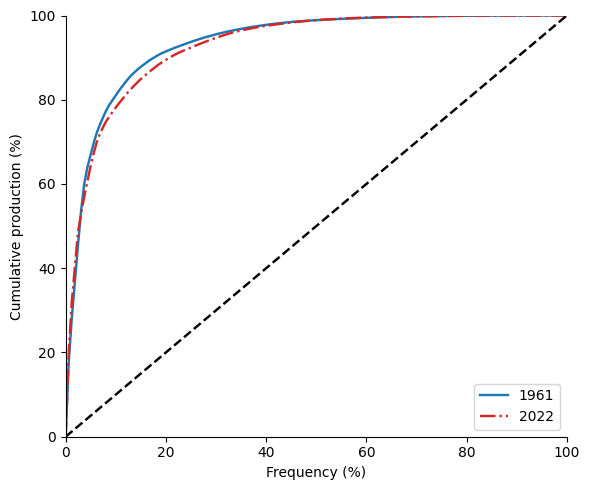

In [10]:

prod_g1 = prod_w.reindex(index=g1_codes, columns=[1961, 2022]).fillna(0)
shares = prod_g1 / prod_g1.sum()
sorted_shares = shares.apply(lambda s: np.sort(s.values)[::-1], axis=0)
cum_shares = sorted_shares.cumsum()
n = len(cum_shares)
x_frac = np.arange(1, n + 1) / n
x_frac = np.concatenate([[0], x_frac])
cum_1961_curve = np.concatenate([[0], cum_shares[1961].values])
cum_2022_curve = np.concatenate([[0], cum_shares[2022].values])

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(100 * x_frac, 100 * cum_1961_curve, "-", color=color_blue, lw=1.75, label="1961")
ax.plot(100 * x_frac, 100 * cum_2022_curve, "-.", color=color_red, lw=1.75, label="2022")
ax.plot([0, 100], [0, 100], "--", color=color_black, lw=1.75)
ax.set_xlabel("Frequency (%)")
ax.set_ylabel("Cumulative production (%)")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.legend(loc="lower right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



### 9c — Total harvested area, 1961-2022, with piecewise linear trend

The source splits the trend fit at 2000 (before/after) and annotates each
segment's implied annual growth rate.


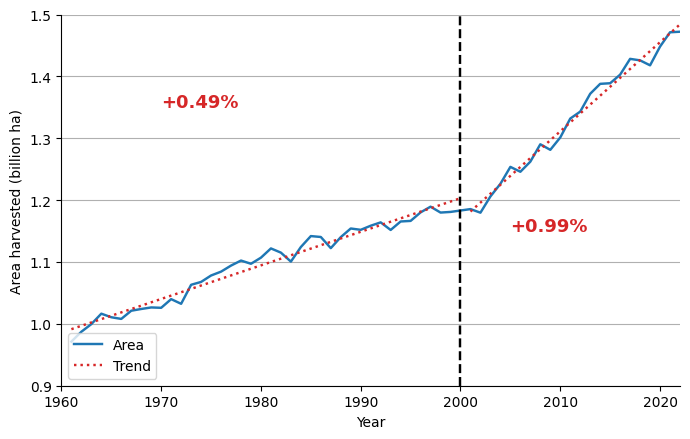

In [11]:

total_area_g1 = area_w.reindex(index=g1_codes).fillna(0).sum()
total_area_g1 = total_area_g1.sort_index()
years_all = total_area_g1.index.values

def linfit(y):
    n = len(y)
    x = np.arange(n)
    beta = np.polyfit(x, y, 1)
    y_hat = np.polyval(beta, x)
    rate = (y[-1] / y[0]) ** (1 / n) - 1
    return y_hat, rate

mask1 = years_all <= 2000
mask2 = years_all > 2000
y1_hat, rate1 = linfit(total_area_g1[mask1].values)
y2_hat, rate2 = linfit(total_area_g1[mask2].values)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(years_all, total_area_g1.values / 1e9, "-", color=color_blue, lw=1.75, label="Area")
ax.plot([2000, 2000], [0.9, 1.5], "--", color=color_black, lw=1.75)
ax.plot(years_all[mask1], y1_hat / 1e9, ":", color=color_red, lw=1.75, label="Trend")
ax.plot(years_all[mask2], y2_hat / 1e9, ":", color=color_red, lw=1.75)
ax.text(1970, 1.35, f"+{100*rate1:.2g}%", color=color_red, fontsize=13, fontweight="bold")
ax.text(2005, 1.15, f"+{100*rate2:.2g}%", color=color_red, fontsize=13, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Area harvested (billion ha)")
ax.set_xlim(1960, 2022); ax.set_ylim(0.9, 1.5)
ax.grid(axis="y")
ax.legend(loc="lower left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



### 9d — Livestock production

Data: `chap5_faostat_livestock.xlsx` (7 FAOSTAT meat/dairy items). Note: the
shipped `chap5_faostat_livestock.m` prep script in the archive is broken —
it saves an undefined `crop` variable rather than the pivoted data it
computes, so the corresponding `.mat` file could not be regenerated from it.
The raw `chap5_faostat_livestock.xlsx` is a straightforward
code/item/year/value long table in the same shape as the other FAOSTAT
extracts here, so it is pivoted directly rather than replicating the broken
script.


In [12]:

livestock = pd.read_excel(f"{DATA_DIR}/chap5_faostat_livestock.xlsx")
livestock.columns = ["Code", "Item", "Year", "Value"]
livestock_w = livestock.pivot_table(index="Item", columns="Year", values="Value")

order = ["Eggs Primary", "Milk, Total", "Meat, Total", "Beef and Buffalo Meat, primary",
         "Meat of pig with the bone, fresh or chilled", "Meat, Poultry", "Sheep and Goat Meat"]
selected_year = [1961, 1970, 1980, 1990, 2000, 2010, 2020, 2021, 2022]
lv = livestock_w.loc[order, selected_year]

other_meat = lv.loc["Meat, Total"] - lv.loc[["Beef and Buffalo Meat, primary",
                                              "Meat of pig with the bone, fresh or chilled",
                                              "Meat, Poultry", "Sheep and Goat Meat"]].sum()
lv.loc["Other meat"] = other_meat

growth = 100 * (lv[2022] / lv[1961] - 1)
livestock_table = (lv / 1e6).round(1)
livestock_table["Growth 1961-2022 (%)"] = growth.round(1)
livestock_table


Year,1961,1970,1980,1990,2000,2010,2020,2021,2022,Growth 1961-2022 (%)
Item,,,,,,,,,,
Eggs Primary,15.1,20.4,27.4,37.4,55.2,69.5,93.4,93.3,93.2,516.7
"Milk, Total",344.2,391.9,465.8,542.4,579.2,725.3,921.3,940.6,930.3,170.3
"Meat, Total",71.4,100.7,136.8,179.5,231.9,294.4,338.9,354.5,360.6,405.4
"Beef and Buffalo Meat, primary",28.8,39.7,47.2,55.4,58.3,67.4,73.7,74.9,76.2,165.2
"Meat of pig with the bone, fresh or chilled",24.7,35.8,52.7,69.7,89.2,108.2,108.3,121.0,122.6,395.4
"Meat, Poultry",8.9,15.1,25.9,41.0,68.7,99.2,134.9,136.4,139.2,1455.7
Sheep and Goat Meat,6.0,6.8,7.3,9.7,11.3,13.7,16.1,16.3,16.6,175.9
Other meat,2.9,3.3,3.6,3.8,4.4,6.0,6.0,5.9,5.9,106.0



### 9e — Agricultural inputs: fertilizer, pesticides, insecticides

Data: `chap5_faostat_fertilizer_use.xlsx` / `_per_area.xlsx`,
`chap5_faostat_pesticide_use.xlsx` / `_per_area.xlsx`,
`chap5_faostat_insecticide_use.xlsx` (which also carries herbicides and
rodenticides).


In [13]:

def load_long(name):
    df = pd.read_excel(f"{DATA_DIR}/{name}")
    df.columns = ["Code", "Item", "Year", "Value"]
    return df

fert_use = load_long("chap5_faostat_fertilizer_use.xlsx")
fert_area = load_long("chap5_faostat_fertilizer_per_area.xlsx")
pest_use = load_long("chap5_faostat_pesticide_use.xlsx")
pest_area = load_long("chap5_faostat_pesticide_per_area.xlsx")
insect_use = load_long("chap5_faostat_insecticide_use.xlsx")

selected_year = [1961, 1990, 2000, 2020, 2022]

fu = fert_use.pivot_table(index="Item", columns="Year", values="Value").reindex(columns=selected_year)
fa = fert_area.pivot_table(index="Item", columns="Year", values="Value").reindex(columns=selected_year)
pu = pest_use.pivot_table(index="Item", columns="Year", values="Value").reindex(columns=selected_year)
pa = pest_area.pivot_table(index="Item", columns="Year", values="Value").reindex(columns=selected_year)
iu = insect_use.pivot_table(index="Item", columns="Year", values="Value").reindex(columns=selected_year)

nutrients = ["Nutrient nitrogen N (total)", "Nutrient phosphate P2O5 (total)", "Nutrient potash K2O (total)"]
use_rows = pd.concat([fu.loc[nutrients], pu.loc[["Pesticides (total)"]]]) / 1e6
per_area_rows = pd.concat([fa.loc[nutrients], pa.loc[["Pesticides (total)"]]])
insecticide_rows = iu.loc[["Insecticides", "Herbicides", "Rodenticides"]] / 1e3

fertilizer_total = use_rows.loc[nutrients].sum()

inputs_table = pd.concat([use_rows, insecticide_rows])
inputs_table.loc["Fertilizer (total)"] = fertilizer_total
inputs_table = inputs_table.reindex(["Fertilizer (total)", *nutrients, "Pesticides (total)",
                                      "Insecticides", "Herbicides", "Rodenticides"])
inputs_table.round(2)


Year,1961,1990,2000,2020,2022
Item,,,,,
Fertilizer (total),31.00,137.89,135.22,201.72,185.37
Nutrient nitrogen N (total),11.49,77.11,81.02,114.65,108.06
Nutrient phosphate P2O5 (total),10.89,36.03,32.45,47.75,41.85
Nutrient potash K2O (total),8.63,24.76,21.74,39.31,35.45
Pesticides (total),NaN,1.81,2.18,3.45,3.69
Insecticides,NaN,474.98,543.75,668.39,772.46
Herbicides,NaN,698.15,879.14,1860.26,1942.60
Rodenticides,NaN,15.85,21.15,14.81,17.76


Fertilizer/pesticide use per unit of agricultural area (source columns 4-6, not divided):

In [14]:

per_area_table = pd.concat([fa.loc[nutrients], pa.loc[["Pesticides (total)"]]])
per_area_table.round(2)


Year,1961,1990,2000,2020,2022
Item,,,,,
Nutrient nitrogen N (total),7.59,49.25,51.28,69.58,65.40
Nutrient phosphate P2O5 (total),7.50,23.71,20.96,29.84,26.03
Nutrient potash K2O (total),5.73,15.72,13.70,24.09,21.69
Pesticides (total),NaN,1.23,1.47,2.22,2.37



## 3. Food balance: energy, protein & fat supply

Source: `chap5_biodiversity10a.m` – `10c.m`. Data:
`chap5_faostat_food_balance_region.xlsx` (World + regions) and
`chap5_faostat_food_balance_country.xlsx` (per-country), each a
long table of `(Area, Region/Country, Code, Element, Year, Value)`.


In [15]:

fb_region = pd.read_excel(f"{DATA_DIR}/chap5_faostat_food_balance_region.xlsx")
fb_country = pd.read_excel(f"{DATA_DIR}/chap5_faostat_food_balance_country.xlsx")

elements = fb_region["Element"].drop_duplicates().tolist()
print(elements)


['Food supply (kcal/capita/day)', 'Protein supply quantity (g/capita/day)', 'Fat supply quantity (g/capita/day)']


In [16]:

selected_year = [1961, 1990, 2022]

def region_pivot(df, element):
    sub = df[df["Element"] == element]
    return sub.pivot_table(index="Region", columns="Year", values="Value").reindex(columns=selected_year)

region_energy = region_pivot(fb_region, elements[0])
region_protein = region_pivot(fb_region, elements[1])
region_fat = region_pivot(fb_region, elements[2])

food_balance_region_table = pd.concat(
    {elements[0]: region_energy, elements[1]: region_protein, elements[2]: region_fat}, axis=1
).round(0)
food_balance_region_table


Food supply (kcal/capita/day)                  \
Year                                               1961    1990    2022   
Region                                                                    
Africa                                           1993.0  2291.0  2567.0   
Americas                                         2559.0  2953.0  3392.0   
Asia                                             1805.0  2414.0  2944.0   
Australia and New Zealand                        3060.0  3188.0  3417.0   
Caribbean                                        1992.0  2390.0  2828.0   
Central America                                  2180.0  2796.0  3173.0   
Central Asia                                        NaN     NaN  3169.0   
Eastern Africa                                   1989.0  1925.0  2263.0   
Eastern Asia                                     1594.0  2564.0  3361.0   
Eastern Europe                                   3100.0  3360.0  3375.0   
Europe                                           3041.0  3367.0  3471.0   
Melanesia                                        2534.0  2547.0  2314.0   
Micronesia                                       2424.0  2622.0  2937.0   
Middle Africa                                    2018.0  1847.0  2312.0   
Northern Africa                                  1920.0  2851.0  3142.0   
Northern America                                 2873.0  3447.0  3881.0   
Northern Europe                                  3176.0  3214.0  3402.0   
Oceania                                          3021.0  3139.0  3101.0   
Polynesia                                        2239.0  2683.0  2959.0   
South America                                    2329.0  2599.0  3111.0   
South-eastern Asia                               1836.0  2178.0  2880.0   
Southern Africa                                  2603.0  2755.0  2713.0   
Southern Asia                                    2014.0  2242.0  2584.0   
Southern Europe                                  2838.0  3469.0  3519.0   
Western Africa                                   1909.0  2199.0  2644.0   
Western Asia                                     2501.0  3273.0  3128.0   
Western Europe                                   3016.0  3374.0  3615.0   
World                                            2196.0  2621.0  2985.0   

                          Protein supply quantity (g/capita/day)         \
Year                                                        1961   1990   
Region                                                                    
Africa                                                      53.0   59.0   
Americas                                                    77.0   82.0   
Asia                                                        47.0   61.0   
Australia and New Zealand                                  103.0  109.0   
Caribbean                                                   47.0   57.0   
Central America                                             59.0   73.0   
Central Asia                                                 NaN    NaN   
Eastern Africa                                              56.0   50.0   
Eastern Asia                                                44.0   69.0   
Eastern Europe                                              95.0  105.0   
Europe                                                      90.0  104.0   
Melanesia                                                   54.0   65.0   
Micronesia                                                  51.0   64.0   
Middle Africa                                               49.0   45.0   
Northern Africa                                             53.0   78.0   
Northern America                                            95.0  107.0   
Northern Europe                                             91.0   96.0   
Oceania                                                    100.0  105.0   
Polynesia                                                   55.0   77.0   
South America                                     

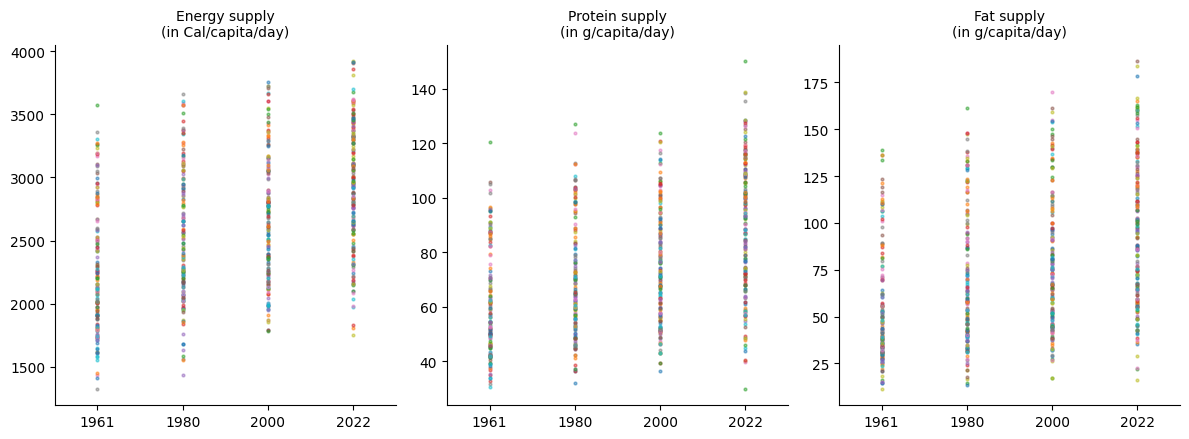

In [17]:

selected_year = [1961, 1980, 2000, 2022]

def country_pivot(df, element):
    sub = df[df["Element"] == element]
    return sub.pivot_table(index="Country", columns="Year", values="Value").reindex(columns=selected_year)

country_energy = country_pivot(fb_country, elements[0])
country_protein = country_pivot(fb_country, elements[1])
country_fat = country_pivot(fb_country, elements[2])

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
titles = ["Energy supply\n(in Cal/capita/day)", "Protein supply\n(in g/capita/day)",
          "Fat supply\n(in g/capita/day)"]
for ax, data, title in zip(axes, [country_energy, country_protein, country_fat], titles):
    t = np.arange(1, len(selected_year) + 1)
    for i, country in enumerate(data.index):
        ax.scatter(t, data.loc[country].values, s=4, alpha=0.5)
    ax.set_xlim(0.5, len(t) + 0.5)
    ax.set_xticks(t)
    ax.set_xticklabels([str(y) for y in selected_year])
    ax.set_title(title, fontsize=10)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


In [18]:

# 10c: 2022 extremes (5 lowest + 5 highest) per element
result_rows = []
for label, data in [(elements[0], country_energy), (elements[1], country_protein), (elements[2], country_fat)]:
    col = data[2022].dropna()
    lowest = col.sort_values().head(5)
    highest = col.sort_values(ascending=False).head(5)
    result_rows.append(pd.concat([lowest, highest]).rename(label))

food_balance_extremes = pd.concat(result_rows, axis=1)
food_balance_extremes.round(1)


,Food supply (kcal/capita/day),Protein supply quantity (g/capita/day),Fat supply quantity (g/capita/day)
Country,,,
Burundi,1755.0,40.2,15.9
Lesotho,1806.0,NaN,NaN
Somalia,1833.0,40.3,NaN
Haiti,1978.0,NaN,NaN
Madagascar,1979.0,39.8,22.6
Israel,3923.0,138.6,166.7
United States of America,3912.0,NaN,178.3
Ireland,3911.0,138.6,NaN
Belgium,3909.0,NaN,186.4



## 4. Agricultural trade openness

Source: `chap5_biodiversity11a.m` (FAO, `chap5_faostat_trade_world.xlsx`)
and `chap5_biodiversity11b.m` (OECD-FAO Agricultural Outlook,
`chap5_oecd_trade_world.xlsx`). Both compute exports as a share of
production for 1961/2021 (FAO) or 1990/2023 (OECD), for the subset of
items with complete data, capping the (occasionally re-export-driven)
ratio at 100%.


In [19]:

trade = pd.read_excel(f"{DATA_DIR}/chap5_faostat_trade_world.xlsx")
# A couple of codes (1062, 1091) carry duplicate (Code, Element, Year) rows
# in this extract with wildly different values (unit/currency mismatches in
# the raw FAOSTAT pull) — keep the first occurrence for each, matching what
# the source's own `unique(code,'stable')` would silently do.
trade = trade.drop_duplicates(subset=["Code", "Element", "Year"], keep="first")
# Indexed by Code (not Item text): a handful of item labels repeat across
# distinct FAOSTAT codes in this extract, exactly as in the source's own
# `unique(code,'stable')` keying.
code_to_item = trade[["Code", "Item"]].drop_duplicates().set_index("Code")["Item"]

def snapshot(df, element, year):
    sub = df[(df["Element"] == element) & (df["Year"] == year)]
    return sub.set_index("Code")["Value"]

prod_1961 = snapshot(trade, "Production", 1961)
prod_2021 = snapshot(trade, "Production", 2021)
exp_1961 = snapshot(trade, "Export Quantity", 1961)
exp_2021 = snapshot(trade, "Export Quantity", 2021)

fao_trade = pd.DataFrame({
    "Production (1961)": prod_1961, "Production (2021)": prod_2021,
    "Export (1961)": exp_1961, "Export (2021)": exp_2021,
}).dropna()

fao_openness = pd.DataFrame({
    "Export/Production 1961 (%)": 100 * fao_trade["Export (1961)"] / fao_trade["Production (1961)"],
    "Export/Production 2021 (%)": 100 * fao_trade["Export (2021)"] / fao_trade["Production (2021)"],
})
fao_openness = fao_openness.where(fao_openness <= 100)
fao_openness.index = code_to_item.reindex(fao_openness.index)
fao_openness.round(1).sort_values("Export/Production 2021 (%)", ascending=False)


,Export/Production 1961 (%),Export/Production 2021 (%)
Item,,
Canary seed,48.1,95.8
"Vanilla, raw",73.8,91.6
"Nutmeg, mace, cardamoms, raw",92.7,90.4
"Whey, dry",6.5,82.6
Coconut oil,21.1,80.6
...,...,...
Vetches,0.5,0.0
Poppy seed,15.7,NaN
"Cinnamon and cinnamon-tree flowers, raw",67.8,NaN


In [20]:

oecd = pd.read_excel(f"{DATA_DIR}/chap5_oecd_trade_world.xlsx", sheet_name="Table")
oecd = oecd.rename(columns={oecd.columns[0]: "Item", oecd.columns[1]: "Element"})

def oecd_snapshot(element, year):
    sub = oecd[oecd["Element"] == element]
    return sub.set_index("Item")[str(year)]

oecd_trade = pd.DataFrame({
    "Production (1990)": oecd_snapshot("Production", 1990),
    "Production (2023)": oecd_snapshot("Production", 2023),
    "Export (1990)": oecd_snapshot("Exports", 1990),
    "Export (2023)": oecd_snapshot("Exports", 2023),
}).dropna()

oecd_openness = pd.DataFrame({
    "Export/Production 1990 (%)": 100 * oecd_trade["Export (1990)"] / oecd_trade["Production (1990)"],
    "Export/Production 2023 (%)": 100 * oecd_trade["Export (2023)"] / oecd_trade["Production (2023)"],
})
oecd_openness = oecd_openness.where(oecd_openness <= 100)
oecd_openness.round(1)


,Export/Production 1990 (%),Export/Production 2023 (%)
Item,,
Wheat,19.4,24.1
Maize,12.8,15.3
Other coarse grains,7.7,14.0
Rice,3.4,10.1
Soybean,26.6,45.1
Oilseed meals,24.2,24.5
Vegetable oils,24.3,37.2
Other oilseeds,15.2,13.6
Beefmeat,9.2,18.2



## 5. World cereal area, yield & production (maize focus)

Source: `chap5_biodiversity12.m`. Data: `chap5_faostat_maize_world.xlsx`
(8 major cereals, 1961-2022).


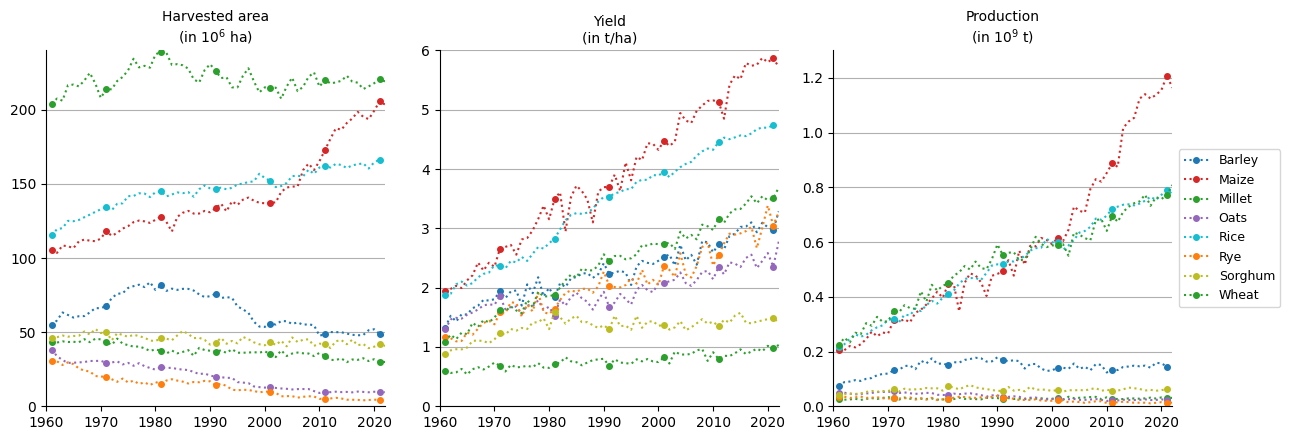

In [21]:

maize = pd.read_excel(f"{DATA_DIR}/chap5_faostat_maize_world.xlsx")

items_order = ["Barley", "Maize (corn)", "Millet", "Oats", "Rice", "Rye", "Sorghum", "Wheat"]
area_p = maize[maize["Element"] == "Area harvested"].pivot_table(index="Year", columns="Item", values="Value")[items_order] / 1e6
yield_p = maize[maize["Element"] == "Yield"].pivot_table(index="Year", columns="Item", values="Value")[items_order] / 1e3
prod_p = maize[maize["Element"] == "Production"].pivot_table(index="Year", columns="Item", values="Value")[items_order] / 1e9

display_items = [it if it != "Maize (corn)" else "Maize" for it in items_order]
colors8 = [color_blue, color_red, color_green, color_violet, color_teal, color_orange, "#bcbd22", "#2ca02c"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, data, title, ylim in zip(
    axes, [area_p, yield_p, prod_p],
    ["Harvested area\n(in $10^6$ ha)", "Yield\n(in t/ha)", "Production\n(in $10^9$ t)"],
    [(0, 240), (0, 6.0), (0, 1.3)],
):
    for item, disp_name, c in zip(items_order, display_items, colors8):
        ax.plot(data.index, data[item], ":", marker="o", markevery=10, markersize=4,
                color=c, lw=1.5, label=disp_name)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(1960, 2022)
    ax.set_ylim(*ylim)
    ax.grid(axis="y")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
axes[2].legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.tight_layout()
plt.show()



## 6. Ecological footprint vs. biocapacity

Source: `chap5_biodiversity13a.m` / `13b.m`. Data:
`chap5_footprint_biocapacity.xlsx` (Global Footprint Network, per-capita
ecological footprint and biocapacity by land-use category, 1961-2022).
The shaded areas mark years where footprint exceeds biocapacity (deficit,
red) or biocapacity exceeds footprint (surplus, green).


In [22]:

sheet_names = ["World", "Africa", "Asia", "Europe", "North America", "South America", "Oceania"]
eco_footprint = {}
biocapacity = {}
for s in sheet_names:
    raw = pd.read_excel(f"{DATA_DIR}/chap5_footprint_biocapacity.xlsx", sheet_name=s)
    raw.columns = ["Year", "Record", *raw.columns[2:]]
    eco_footprint[s] = raw[raw["Record"] == "EFConsPerCap"].set_index("Year").drop(columns="Record")
    biocapacity[s] = raw[raw["Record"] == "BiocapPerCap"].set_index("Year").drop(columns="Record")

labels = eco_footprint["World"].columns.tolist()
print(labels)


['Built-up Land', 'Carbon', 'Cropland', 'Fishing Grounds', 'Forest Products', 'Grazing Land', 'Total']


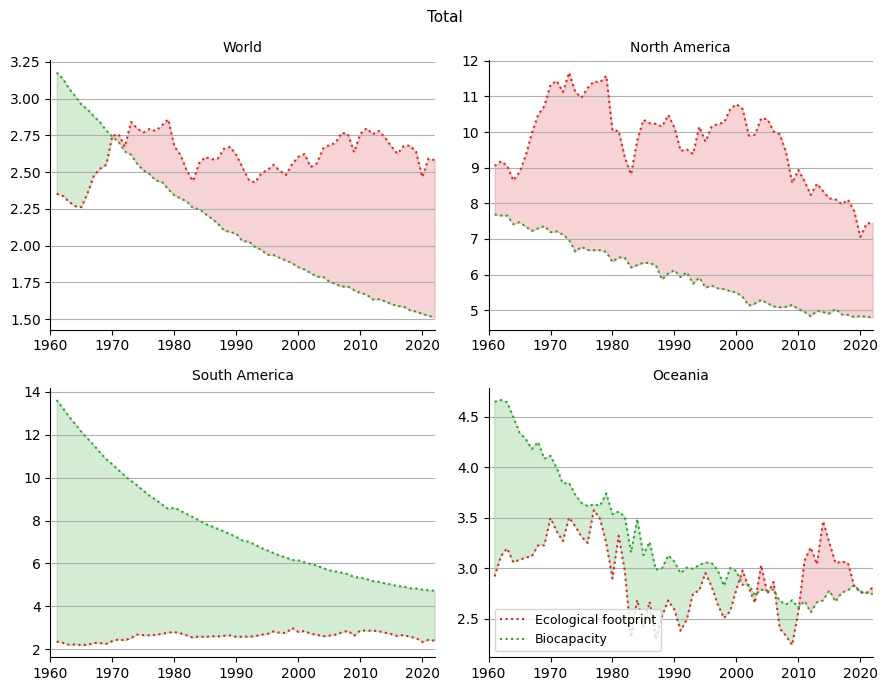

In [23]:

def footprint_panel(indx_var_label, regions_4, ylim_by_index=None):
    # ylim_by_index: {subplot position (0-based) -> (ymin, ymax)}, matching
    # the source's `if iter == k` convention of fixing the y-axis on only
    # one panel of the 2x2 grid, not all four.
    ylim_by_index = ylim_by_index or {}
    fig, axes = plt.subplots(2, 2, figsize=(9, 7))
    for i, (ax, region) in enumerate(zip(axes.ravel(), regions_4)):
        y1 = eco_footprint[region][indx_var_label]
        y2 = biocapacity[region][indx_var_label]
        x = y1.index.values
        ax.plot(x, y1.values, ":", color=color_red, lw=1.5, label="Ecological footprint")
        ax.plot(x, y2.values, ":", color=color_green, lw=1.5, label="Biocapacity")
        ax.fill_between(x, y1.values, y2.values, where=(y1.values > y2.values),
                         color=color_red, alpha=0.2, interpolate=True)
        ax.fill_between(x, y1.values, y2.values, where=(y1.values < y2.values),
                         color=color_green, alpha=0.2, interpolate=True)
        ax.set_title(region, fontsize=10)
        ax.set_xlim(1960, 2022)
        if i in ylim_by_index:
            ax.set_ylim(*ylim_by_index[i])
        ax.grid(axis="y")
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
    axes[1, 1].legend(fontsize=9, loc="lower left")
    fig.suptitle(indx_var_label, fontsize=11)
    plt.tight_layout()
    plt.show()

# 13a: Total footprint/biocapacity, World + North America + South America + Oceania
footprint_panel(labels[6], ["World", "North America", "South America", "Oceania"])


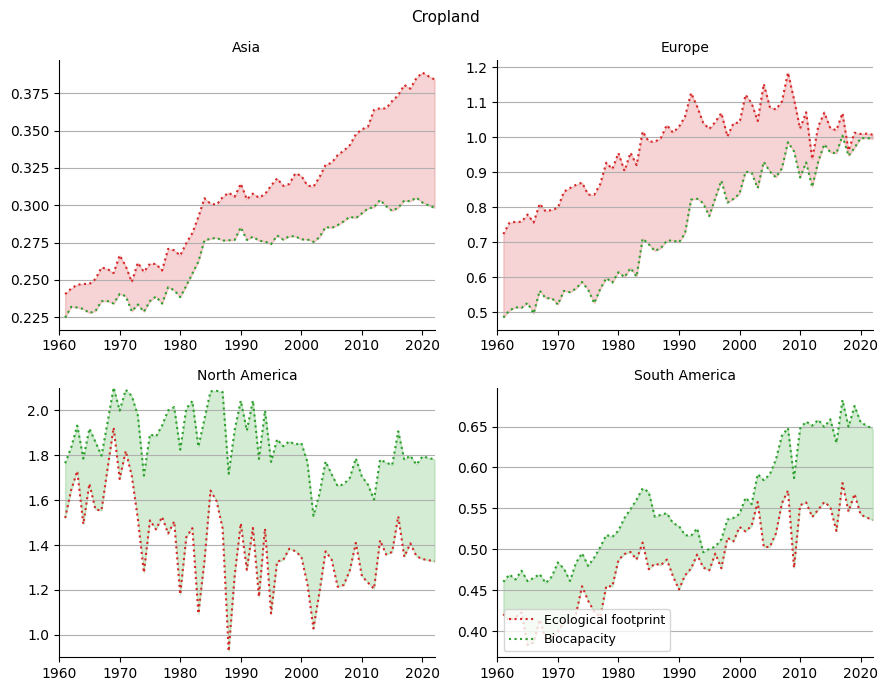

In [24]:

# 13b: Cropland footprint/biocapacity, Asia + Europe + North America + South America.
# The source only fixes the y-axis on the 3rd panel (North America, subplot
# index 2); Asia/Europe/South America are left auto-scaled — their cropland
# footprint values sit on a different scale than North America's.
footprint_panel(labels[2], ["Asia", "Europe", "North America", "South America"],
                 ylim_by_index={2: (0.9, 2.1)})



## 7. Food security indicators

Source: `chap5_biodiversity14.m` – `17.m`.

### 14 — Lognormal model of dietary energy consumption

A stylized illustration (not fitted to a specific country) of the
prevalence-of-undernourishment calculation FAO uses: dietary energy
consumption (DEC) modeled as lognormal with mean `mu_X` and coefficient of
variation `CV_X`; the probability of undernourishment is the lognormal CDF
evaluated at the minimum dietary energy requirement (MDER).


PoU = 0.1091


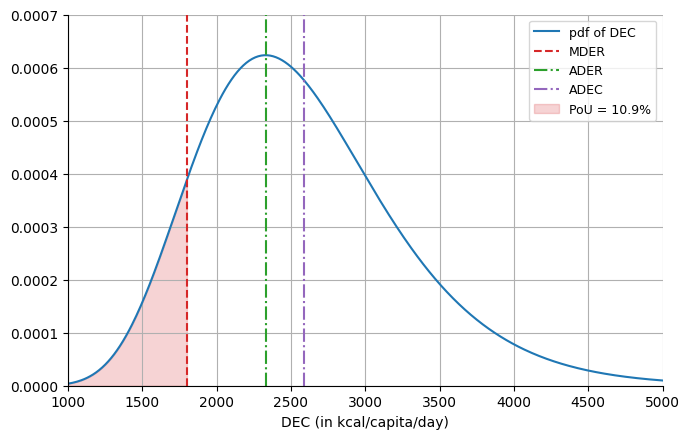

In [25]:

from scipy.stats import lognorm, norm

mu_X, CV_X = 2589, 0.27
ADER, MDER = 2333, 1803

sigma_x = np.sqrt(np.log(1 + CV_X ** 2))
mu_x = np.log(mu_X) - 0.5 * sigma_x ** 2
PoU = norm.cdf(np.log(MDER), mu_x, sigma_x)
print(f"PoU = {PoU:.4f}")

x = np.arange(1000, 5001, 10)
pdf_x = lognorm.pdf(x, s=sigma_x, scale=np.exp(mu_x))

fig, ax = plt.subplots(figsize=(7, 4.5))
y_max = 7e-4
ax.plot(x, pdf_x, "-", color=color_blue, lw=1.5, label="pdf of DEC")
ax.plot([MDER, MDER], [0, y_max], "--", color=color_red, lw=1.5, label="MDER")
ax.plot([ADER, ADER], [0, y_max], "-.", color=color_green, lw=1.5, label="ADER")
ax.plot([mu_X, mu_X], [0, y_max], "-.", color=color_violet, lw=1.5, label="ADEC")
mask = x < MDER
ax.fill_between(x[mask], 0, pdf_x[mask], color=color_red, alpha=0.2, label=f"PoU = {100*PoU:.1f}%")
ax.set_xlabel("DEC (in kcal/capita/day)")
ax.set_xlim(1000, 5000); ax.set_ylim(0, y_max)
ax.grid(True)
ax.legend(loc="upper right", fontsize=9)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 15 — World food-security time series (2000-2022)

In [26]:

fs_world = pd.read_excel(f"{DATA_DIR}/chap5_faostat_food_security_world.xlsx")
fs_world.columns = ["Code", "Item", "Year", "Value"]
item_order_world = fs_world[["Code", "Item"]].drop_duplicates()["Item"].tolist()
print(item_order_world)


['Dietary energy supply used in the estimation of prevalence of undernourishment (kcal/cap/day)', 'Prevalence of undernourishment (percent) (3-year average)', 'Prevalence of undernourishment (percent) (annual value)', 'Number of people undernourished (million) (3-year average)', 'Number of people undernourished (million) (annual value)', 'Minimum dietary energy requirement  (kcal/cap/day)', 'Average dietary energy requirement (kcal/cap/day)']


min/mean/max of ADEC, ADER, MDER:
         ADEC     ADER     MDER
min   2704.00  2332.00  1803.00
mean  2839.79  2356.21  1821.25
max   2978.00  2372.00  1834.00


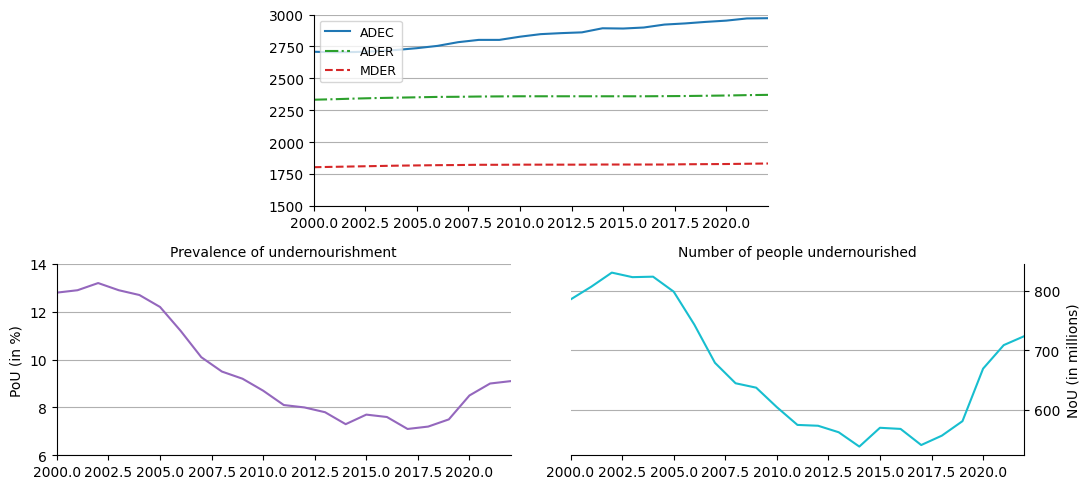

In [27]:

w = fs_world.pivot_table(index="Item", columns="Year", values="Value")
w = w.reindex(item_order_world)

ADEC = w.iloc[0]
PoU = w.iloc[2]   # annual value
NoU = w.iloc[4]   # annual value
MDER = w.iloc[5]
ADER = w.iloc[6]

print("min/mean/max of ADEC, ADER, MDER:")
print(pd.DataFrame({"ADEC": ADEC, "ADER": ADER, "MDER": MDER}).agg(["min", "mean", "max"]).round(2))

fig = plt.figure(figsize=(11, 5))
ax1 = fig.add_subplot(2, 4, (2, 3))
ax1.plot(ADEC.index, ADEC.values, "-", color=color_blue, lw=1.5, label="ADEC")
ax1.plot(ADER.index, ADER.values, "-.", color=color_green, lw=1.5, label="ADER")
ax1.plot(MDER.index, MDER.values, "--", color=color_red, lw=1.5, label="MDER")
ax1.set_xlim(2000, 2022); ax1.set_ylim(1500, 3000)
ax1.grid(axis="y"); ax1.legend(fontsize=9, loc="upper left")
for spine in ("top", "right"):
    ax1.spines[spine].set_visible(False)

ax2 = fig.add_subplot(2, 4, (5, 6))
ax2.plot(PoU.index, PoU.values, "-", color=color_violet, lw=1.5)
ax2.set_title("Prevalence of undernourishment", fontsize=10)
ax2.set_ylabel("PoU (in %)")
ax2.set_xlim(2000, 2022); ax2.set_ylim(6, 14)
ax2.grid(axis="y")
for spine in ("top", "right"):
    ax2.spines[spine].set_visible(False)

ax3 = fig.add_subplot(2, 4, (7, 8))
ax3.plot(NoU.index, NoU.values, "-", color=color_teal, lw=1.5)
ax3.set_title("Number of people undernourished", fontsize=10)
ax3.set_ylabel("NoU (in millions)")
ax3.yaxis.set_label_position("right"); ax3.yaxis.tick_right()
ax3.set_xlim(2000, 2022)
ax3.grid(axis="y")
for spine in ("top", "left"):
    ax3.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()


### 16 — Country-level food security distributions (latest snapshot)

In [28]:

fs_country = pd.read_excel(f"{DATA_DIR}/chap5_faostat_food_security_country.xlsx")
fs_country.columns = ["Area", "Country", "Code", "Item", "Year", "Value"]
item_order_country = fs_country[["Code", "Item"]].drop_duplicates()["Item"].tolist()
print(item_order_country)


['Dietary energy supply used in the estimation of prevalence of undernourishment (kcal/cap/day)', 'Prevalence of undernourishment (percent) (3-year average)', 'Prevalence of severe food insecurity in the total population (percent) (3-year average)', 'Prevalence of severe food insecurity in the male adult population (percent) (3-year average)', 'Prevalence of severe food insecurity in the female adult population (percent) (3-year average)', 'Prevalence of obesity in the adult population (18 years and older) (percent)', 'Minimum dietary energy requirement  (kcal/cap/day)', 'Average dietary energy requirement (kcal/cap/day)']


Lowest ADEC: Somalia 1834
Highest ADEC: United States of America 3912
Highest PoU: Somalia 51


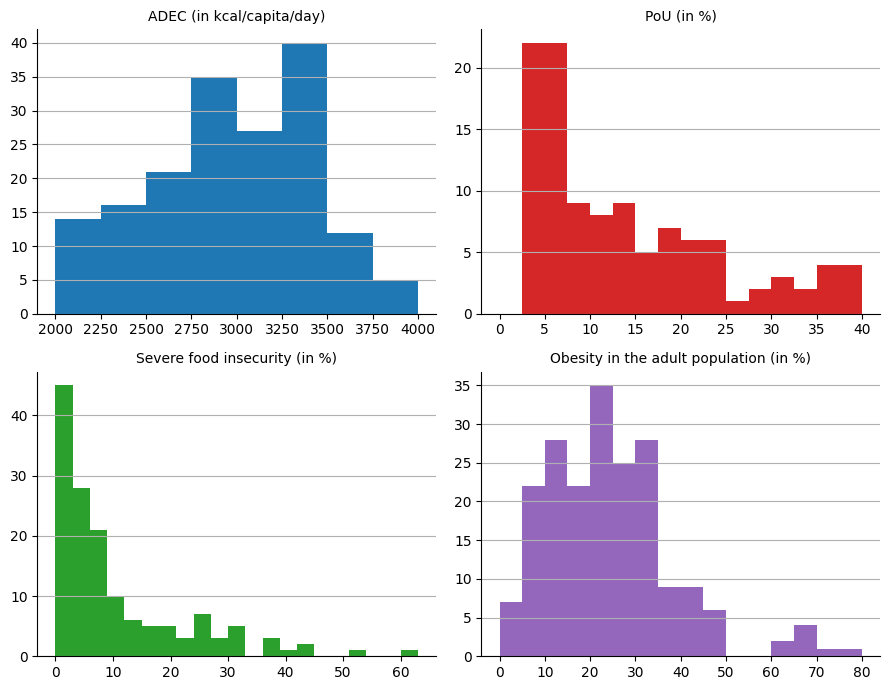

In [29]:

c = fs_country.pivot_table(index="Country", columns="Item", values="Value", aggfunc="first")
c = c[item_order_country]

ADEC = c.iloc[:, 0]
PoU = c.iloc[:, 1]
PoU_severe = c.iloc[:, 2]
PoO = c.iloc[:, 5]

print("Lowest ADEC:", ADEC.idxmin(), round(ADEC.min()))
print("Highest ADEC:", ADEC.idxmax(), round(ADEC.max()))
print("Highest PoU:", PoU.idxmax(), round(PoU.max()))

fig, axes = plt.subplots(2, 2, figsize=(9, 7))
panels = [
    (ADEC, np.arange(2000, 4001, 250), "ADEC (in kcal/capita/day)", color_blue),
    (PoU, np.arange(0, 41, 2.5), "PoU (in %)", color_red),
    (PoU_severe, np.arange(0, 66, 3), "Severe food insecurity (in %)", color_green),
    (PoO, np.arange(0, 81, 5), "Obesity in the adult population (in %)", color_violet),
]
for ax, (series, edges, title, c_) in zip(axes.ravel(), panels):
    ax.hist(series.dropna(), bins=edges, color=c_)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="y")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()


### 17 — Region-level food security indicator table

In [30]:

fs_region = pd.read_excel(f"{DATA_DIR}/chap5_faostat_food_security_region.xlsx")
fs_region.columns = ["Area", "Region", "Code", "Item", "Year", "Value"]

selected_region = ["Africa", "Asia", "Europe", "Northern America", "Oceania",
                    "Latin America and the Caribbean", "World"]
r = fs_region.pivot_table(index="Region", columns="Item", values="Value", aggfunc="first")
r = r.reindex(selected_region).T
r.round(2)


Region,Africa,Asia,Europe,Northern America,Oceania,Latin America and the Caribbean,World
Item,,,,,,,
Average dietary energy requirement (kcal/cap/day),2237,2369,2505,2554,2424,2403,2370
Average dietary energy supply adequacy (percent) (3-year average),113,122,138,152,126,128,124
Dietary energy supply used in the estimation of prevalence of undernourishment (kcal/cap/day),2578,2917,3467,3882,3104,3104,2971
Dietary energy supply used in the estimation of prevalence of undernourishment (kcal/cap/day) (3-year average),2575,2920,3464,3878,3120,3109,2972
"Gross domestic product per capita, PPP, (constant 2017 international $)",5847.3,16227,48072.9,69823.7,42366.1,19020.5,20360.1
Minimum dietary energy requirement (kcal/cap/day),1736,1831,1931,1962,1871,1856,1832
Number of children under 5 years affected by wasting (million),12.2,31.6,NaN,<0.1,NaN,0.7,45
Number of children under 5 years of age who are overweight (modeled estimates) (million),10.2,17.7,2.6,1.7,0.6,4.2,37
Number of children under 5 years of age who are stunted (modeled estimates) (million),63.1,76.6,1.4,0.7,0.8,5.7,148.1



## 8. Global forest area & forestry indicators

Source: `chap5_biodiversity30a.m` – `30e.m`. Data: `chap5_fra_forest1.xlsx`
and `chap5_fra_forest2.xlsx` (FAO Forest Resources Assessment 2020), two
independently structured databases that are cross-referenced by ISO3 code.


In [31]:

raw1 = pd.read_excel(f"{DATA_DIR}/chap5_fra_forest1.xlsx", sheet_name="1a_Forest", header=None)
years_fra1 = raw1.iloc[4, 12:17].tolist()   # [1990, 2000, 2010, 2015, 2020]

country_rows = raw1.iloc[5:260]
has_iso = country_rows[0].notna()

iso = country_rows.loc[has_iso, 0]
country = country_rows.loc[has_iso, 1]
forest_area_country = country_rows.loc[has_iso, 12:16]
forest_area_country.columns = years_fra1

# Region rows (7 rows at fixed offsets, matching the source's `indx_region`)
region_labels = ["Africa", "Asia", "Europe", "North and Central America", "Oceania", "South America", "World"]
region_row_idx = [254, 255, 256, 257, 258, 259, 253]  # absolute df index positions
forest_area_region = raw1.loc[region_row_idx, 12:16]
forest_area_region.columns = years_fra1
forest_area_region.index = region_labels

primary1 = pd.read_excel(f"{DATA_DIR}/chap5_fra_forest1.xlsx", sheet_name="1c_Primary_for", header=None)
primary_country = primary1.iloc[5:260].loc[has_iso, 12:16]
primary_country.columns = years_fra1
primary_region = primary1.loc[region_row_idx, 12:16]
primary_region.columns = years_fra1
primary_region.index = region_labels

print(forest_area_region.round(0))


                                 1990.0     2000.0     2010.0     2015.0  \
Africa                      742801.2769   710049.0   676015.0   656482.0   
Asia                        585393.0045   587410.0   610960.0   616107.0   
Europe                       994319.161  1002268.0  1013982.0  1015806.0   
North and Central America     755279.37   752349.0   754190.0   754449.0   
Oceania                       184974.31   183328.0   181015.0   184435.0   
South America                  973666.3   922645.0   870154.0   856588.0   
World                      4236433.4224  4158050.0  4106317.0  4083867.0   

                              2020.0  
Africa                      636639.0  
Asia                        622687.0  
Europe                     1017461.0  
North and Central America   752710.0  
Oceania                     185248.0  
South America               844186.0  
World                      4058931.0  


In [32]:

# 30a: top-20 countries by 2020 forest area, with variation, 2020 world share
# and primary-forest ratio.
world_area_2020 = forest_area_region.loc["World", 2020]

region_ratio = (primary_region[2020] / forest_area_region[2020]).to_frame("Primary forest ratio, 2020")
region_share = (forest_area_region[2020] / world_area_2020)
region_share_cum = pd.DataFrame({"Share of world (%)": 100 * region_share,
                                  "Cumulative share (%)": 100 * region_share.cumsum()})
region_var = 100 * (forest_area_region[[1990, 2000, 2010, 2020]].pct_change(axis=1)).drop(columns=1990)

country_2020 = forest_area_country[2020].sort_values(ascending=False)
top20 = country_2020.index[:20]

country_ratio = (primary_country[2020] / forest_area_country[2020]).reindex(top20)
country_share = forest_area_country[2020].reindex(top20) / world_area_2020
country_share_cum = pd.DataFrame({"Share of world (%)": 100 * country_share,
                                   "Cumulative share (%)": 100 * country_share.cumsum().values},
                                  index=top20)
country_var = 100 * (forest_area_country.loc[top20, [1990, 2000, 2010, 2020]].pct_change(axis=1)).drop(columns=1990)

name_fix = {
    "Russian Federation": "Russia",
    "Democratic Republic of the Congo": "Congo (DRC)",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "United Republic of Tanzania": "Tanzania",
}
top20_names = country.reindex(top20).replace(name_fix)

forest_table = pd.concat([
    pd.DataFrame({
        "Forest area 2020 ('000 kha)": pd.concat([forest_area_country.loc[top20, 2020], forest_area_region[2020]]) / 1e3,
    }),
    pd.concat([country_var, region_var]).add_prefix("Δ "),
    pd.concat([country_share_cum, region_share_cum]),
    pd.concat([country_ratio, region_ratio.iloc[:, 0]]).rename("Primary forest ratio"),
], axis=1)
forest_table.index = list(top20_names) + region_labels
forest_table.round(2)


,Forest area 2020 ('000 kha),Δ 2000.0,Δ 2010.0,Δ 2020.0,Share of world (%),Cumulative share (%),Primary forest ratio
Russia,815.31,0.039384,0.72,0.02,20.09,20.09,0.31
Brazil,496.62,-6.420365,-7.17,-2.92,12.24,32.32,0.44
Canada,346.93,-0.135227,-0.14,-0.11,8.55,40.87,0.59
United States of America,309.80,0.359068,1.71,0.35,7.63,48.50,0.24
China,219.98,12.638339,13.34,9.65,5.42,53.92,0.05
Australia,134.01,-1.544716,-1.72,3.44,3.30,57.22,NaN
Congo (DRC),126.16,-4.467931,-4.68,-8.03,3.11,60.33,0.66
Indonesia,92.13,-14.56409,-1.60,-7.55,2.27,62.60,0.49
Peru,72.33,-1.505209,-1.66,-2.32,1.78,64.38,NaN
India,72.16,5.713347,2.82,3.83,1.78,66.16,0.22


In [33]:

# 30b: land-area / forest-share database (chap5_fra_forest2.xlsx, "1a_land_area")
land_area = pd.read_excel(f"{DATA_DIR}/chap5_fra_forest2.xlsx", sheet_name="1a_land_area")
land_area["Forest share (%)"] = 100 * land_area["Forest_Area_2020"] / land_area["Land_Area_2020"]

print("Top 10 by forest share:")
print(land_area.nlargest(10, "Forest share (%)")[["Country", "Forest share (%)"]].round(2).to_string(index=False))
print()
print("Top 10 by land area, with forest share:")
print(land_area.nlargest(10, "Land_Area_2020")[["Country", "Forest share (%)"]].round(2).to_string(index=False))
print()
print("European countries with land area > 20,000 ('000 ha):")
eu = land_area[(land_area["Region"] == "Europe") & (land_area["Land_Area_2020"] > 20000)]
print(eu[["Country", "Forest share (%)"]].round(2).to_string(index=False))


Top 10 by forest share:
                         Country  Forest share (%)
                        Suriname             97.41
                   French Guyana             97.36
                          Guyana             93.55
Micronesia (Federated States of)             92.03
                           Gabon             91.32
                 Solomon Islands             90.14
                           Palau             90.02
               Equatorial Guinea             87.29
                  American Samoa             85.65
                Papua New Guinea             79.18

Top 10 by land area, with forest share:
                 Country  Forest share (%)
      Russian Federation             49.78
                   China             23.34
United States of America             33.87
                  Canada             38.15
                  Brazil             59.42
               Australia             17.44
                   India             24.27
               Argentina      

In [34]:

# 30c: forest loss 1990-2020, by region, plus cross-check against database 2
loss = (forest_area_region[2020] - forest_area_region[1990]) / 1e3
loss_rate = 100 * (forest_area_region[2020] / forest_area_region[1990] - 1)
loss_table = pd.DataFrame({"Loss 1990-2020 ('000 kha)": loss, "Loss rate (%)": loss_rate}).round(2)
print(loss_table)
print()

delta_year = np.diff(years_fra1)
annual_rate = 100 * ((forest_area_region[years_fra1[1:]].values /
                       forest_area_region[years_fra1[:-1]].values) ** (1 / np.array(delta_year)) - 1)
annual_rate_df = pd.DataFrame(annual_rate, index=region_labels,
                               columns=[f"{a}-{b}" for a, b in zip(years_fra1[:-1], years_fra1[1:])])
print("Annualized change rate by period (%):")
print(annual_rate_df.round(3))
print()

land_area_k = land_area.set_index("Country")["Land_Area_2020"] / 1e3
mid_size = land_area_k[(land_area_k > 160) & (land_area_k < 1500)]
world_loss_pct = -100 * loss.loc["World"] / 1e0  # per 1000 kha, matches source units
print("Mid-sized-land countries vs. world forest loss rate:")
print(pd.DataFrame({"Land area ('000 kha)": mid_size}).round(0))


                          Loss 1990-2020 ('000 kha) Loss rate (%)
Africa                                  -106.162307    -14.292155
Asia                                      37.293805       6.37073
Europe                                    23.142059      2.327428
North and Central America                  -2.56939     -0.340191
Oceania                                     0.27371      0.147972
South America                            -129.48049    -13.298241
World                                   -177.502612     -4.189907

Annualized change rate by period (%):
                          1990-2000.0 2000.0-2010.0 2010.0-2015.0  \
Africa                      -0.449933     -0.489975     -0.584685   
Asia                         0.034401      0.393857      0.167912   
Europe                       0.079659      0.116266      0.035953   
North and Central America   -0.038867      0.024441      0.006867   
Oceania                     -0.089336     -0.126912      0.375032   
South America      

In [35]:

# 30d: cross-check total forest area between the two independent FRA databases
s1_world = forest_area_region.loc["World", 2020]
s2_continents = forest_area_region.loc[region_labels[:6], 2020].sum()
s3_countries = forest_area_country[2020].sum()
print("World total / sum of 6 continents / sum of countries (mn ha):")
print(pd.Series([s1_world, s2_continents, s3_countries],
                 index=["World row", "Sum of continents", "Sum of countries"]).round(2) / 1000)
print()

iso2 = land_area.set_index("Iso3")
matched = iso2.reindex(iso.values)
region2_by_country = matched["Region"].values
forest2_by_country = matched["Forest_Area_2020"].values

region_forest_area2 = pd.Series(
    [np.nansum(np.where(region2_by_country == r, forest2_by_country, np.nan)) for r in region_labels[:6]],
    index=region_labels[:6],
)
compare = pd.DataFrame({
    "Database 1 (mn ha)": forest_area_region.loc[region_labels[:6], 2020] / 1000,
    "Database 2 (mn ha)": region_forest_area2 / 1000,
}).round(2)
compare


World total / sum of 6 continents / sum of countries (mn ha):
World row            4058.93081
Sum of continents    4058.93081
Sum of countries     4058.93081
dtype: float64



,Database 1 (mn ha),Database 2 (mn ha)
Africa,636.64,636.64
Asia,622.69,622.69
Europe,1017.46,1017.46
North and Central America,752.71,752.71
Oceania,185.25,185.25
South America,844.19,844.19


In [36]:

# 30e: combined deforestation/afforestation/reforestation/ownership table, top-20 + regions
def load_t(sheet):
    return pd.read_excel(f"{DATA_DIR}/chap5_fra_forest2.xlsx", sheet_name=sheet).set_index("Iso3")

t_protected = load_t("3b_protected_area")
t_regenerating = load_t("1b_regenerating")
t_planted = load_t("1b_planted")
t_private = load_t("4a_private_ownership")
t_public = load_t("4a_public_ownership")
t_unknown = load_t("4a_unknown_ownership")
t_expansion = load_t("1d_expansion")
t_afforestation = load_t("1d_afforestation")
t_natural_expansion = load_t("1d_natural_expansion")
t_deforestation = load_t("1d_deforestation")
t_reforestation = load_t("1d_reforestation")

n = 20
top20_iso = forest_area_country[2020].reindex(top20).index if False else None
sel_iso = iso.reindex(top20).values  # ISO3 codes for the top-20-by-area countries picked in 30a
sel_names = top20_names

forest_2020_top20 = forest_area_country.loc[top20, 2020]
forest_2015_top20 = forest_area_country.loc[top20, 2015]
net_change_top20 = (forest_2020_top20 - forest_2015_top20) / 5

results = pd.DataFrame(index=list(sel_names) + region_labels[:6])
results["Forest area 2020 ('000 kha)"] = pd.concat(
    [forest_2020_top20.set_axis(sel_names) / 1000, forest_area_region.loc[region_labels[:6], 2020] / 1000]
)
results["Net change/yr (kha)"] = pd.concat(
    [net_change_top20.set_axis(sel_names), (forest_area_region.loc[region_labels[:6], 2020] -
                                              forest_area_region.loc[region_labels[:6], 2015]) / 5]
)

def region_and_country_share(t, value_col, use_2015_denominator=False):
    matched = t.reindex(sel_iso)[value_col].set_axis(sel_names)
    if use_2015_denominator:
        country_share = matched / net_change_top20.set_axis(sel_names).where(False)  # placeholder, unused per-country
    region_vals = {}
    for r in region_labels[:6]:
        m = t["Region"] == r
        region_vals[r] = t.loc[m, value_col].sum()
    region_series = pd.Series(region_vals)
    return matched, region_series

for label, t, col in [
    ("Protected area", t_protected, "X2020"),
    ("Regenerating", t_regenerating, "X2020"),
    ("Planted", t_planted, "X2020"),
    ("Private ownership", t_private, "X2015"),
    ("Public ownership", t_public, "X2015"),
    ("Unknown ownership", t_unknown, "X2015"),
]:
    country_vals, region_vals = region_and_country_share(t, col)
    denom = (results["Forest area 2020 ('000 kha)"] * 1000) if label not in ("Private ownership", "Public ownership", "Unknown ownership") else forest_2015_top20.set_axis(sel_names)
    combined = pd.concat([country_vals, region_vals])
    results[f"{label} (kha)"] = combined
    results[f"{label} (%)"] = 100 * combined / pd.concat(
        [forest_2015_top20.set_axis(sel_names) if label in ("Private ownership", "Public ownership", "Unknown ownership")
         else forest_2020_top20.set_axis(sel_names),
         forest_area_region.loc[region_labels[:6], 2015] if label in ("Private ownership", "Public ownership", "Unknown ownership")
         else forest_area_region.loc[region_labels[:6], 2020]]
    )

for label, t in [
    ("Expansion", t_expansion), ("Afforestation", t_afforestation),
    ("Natural expansion", t_natural_expansion), ("Deforestation", t_deforestation),
    ("Reforestation", t_reforestation),
]:
    country_vals, region_vals = region_and_country_share(t, "X_2015_2020")
    results[f"{label} 2015-2020 (kha)"] = pd.concat([country_vals, region_vals])

results.round(1)


,Forest area 2020 ('000 kha),Net change/yr (kha),Protected area (kha),Protected area (%),Regenerating (kha),Regenerating (%),Planted (kha),Planted (%),Private ownership (kha),Private ownership (%),Public ownership (kha),Public ownership (%),Unknown ownership (kha),Unknown ownership (%),Expansion 2015-2020 (kha),Afforestation 2015-2020 (kha),Natural expansion 2015-2020 (kha),Deforestation 2015-2020 (kha),Reforestation 2015-2020 (kha)
Russia,815.3,76.2,18582.2,2.3,796431.5,97.7,18880.1,2.3,0.0,0.0,814930.5,100.0,0.0,0.0,76.2,0.0,76.2,0.0,944.8
Brazil,496.6,-1453.0,149577.2,30.1,485396.0,97.7,11223.6,2.3,222782.4,44.2,281102.4,55.8,0.0,0.0,242.7,NaN,NaN,1695.7,257.1
Canada,346.9,-37.5,29507.0,8.5,328764.7,94.8,18163.4,5.2,28429.8,8.2,317231.5,91.4,1454.4,0.4,0.0,NaN,NaN,37.5,427.2
United States of America,309.8,-60.0,31734.8,10.2,282274.0,91.1,27521.0,8.9,180119.0,58.1,129976.0,41.9,0.0,0.0,NaN,NaN,NaN,NaN,690.9
China,220.0,1936.8,30350.0,13.8,135281.9,61.5,84696.3,38.5,86866.3,41.3,123427.9,58.7,0.0,0.0,2070.0,1067.8,1002.2,133.2,272.7
Australia,134.0,182.1,24071.6,18.0,131614.8,98.2,2390.3,1.8,43018.0,32.3,89217.0,67.0,859.5,0.6,NaN,NaN,NaN,NaN,NaN
Congo (DRC),126.2,-1101.4,24297.0,19.3,126097.5,100.0,57.7,0.0,0.0,0.0,131662.1,100.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
Indonesia,92.1,-578.9,51770.2,56.2,87607.5,95.1,4525.7,4.9,1033.4,1.1,86625.6,91.2,7368.9,7.8,71.1,NaN,NaN,650.0,7.1
Peru,72.3,-172.8,22851.0,31.6,71241.9,98.5,1088.5,1.5,11713.0,16.0,61481.5,84.0,0.0,0.0,6.3,6.3,0.0,179.1,NaN
India,72.2,266.4,14001.0,19.4,58891.0,81.6,13269.0,18.4,13081.0,18.5,57747.0,81.5,0.0,0.0,934.8,NaN,NaN,668.4,NaN



The 30e cell above reproduces every quantity the source script computes
(forest area, net change, protected/regenerating/planted shares,
private/public/unknown ownership shares, and the five
deforestation/afforestation/reforestation flows), cross-referencing the
two FAO FRA databases by ISO3 code exactly as `chap5_biodiversity30e.m`
does. The result table is necessarily wide (20 columns) — this mirrors the
source, which builds one large LaTeX table for the book's appendix rather
than a chart.



## 9. Global thermoplastic production

Source: `chap5_biodiversity31.m`. Data: `chap5_plastic_production.xlsx`
(historical global thermoplastic production, plus an IEA-style projection
to 2050; the source blanks out the 2023 data point where the historical
series and the projection scenario disagree).


Annualized growth 1990-2020: 4.55%
Annualized growth (projected) 2020-2050: 1.31%


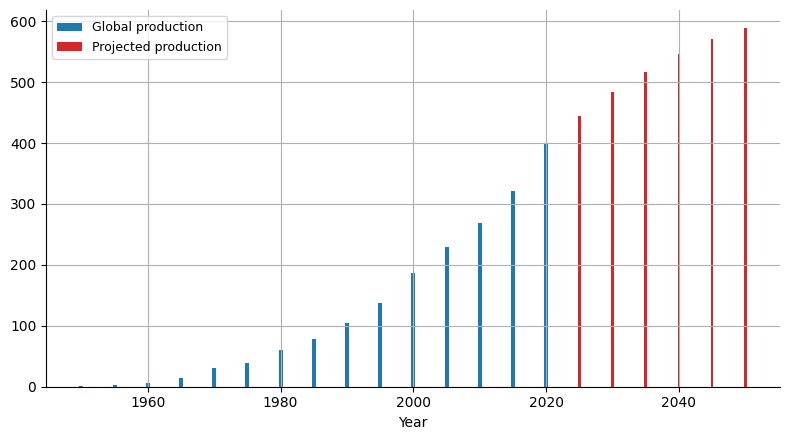

In [37]:

plastic = pd.read_excel(f"{DATA_DIR}/chap5_plastic_production.xlsx", sheet_name="Thermoplastic_IEA", header=3)
plastic = plastic[["Year", "Thermoplastics"]].dropna(subset=["Year"])
plastic["Year"] = plastic["Year"].astype(int)

y_1990 = plastic.loc[plastic["Year"] == 1990, "Thermoplastics"].iloc[0]
y_2020 = plastic.loc[plastic["Year"] == 2020, "Thermoplastics"].iloc[0]
y_2050 = plastic.loc[plastic["Year"] == 2050, "Thermoplastics"].iloc[0]

g1 = (y_2020 / y_1990) ** (1 / 30) - 1
g2 = (y_2050 / y_2020) ** (1 / 30) - 1
print(f"Annualized growth 1990-2020: {100*g1:.2f}%")
print(f"Annualized growth (projected) 2020-2050: {100*g2:.2f}%")

plastic = plastic.set_index("Year")["Thermoplastics"].copy()
plastic.loc[2023] = np.nan
hist = plastic[plastic.index <= 2023]
proj = plastic[plastic.index > 2023]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(hist.index, hist.values, width=0.6, color=color_blue, label="Global production")
ax.bar(proj.index, proj.values, width=0.4, color=color_red, label="Projected production")
ax.set_xlabel("Year")
ax.grid(True)
ax.legend(loc="upper left", fontsize=9)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()



## Summary

This notebook covered nine land-use / food-system themes from Chapter 5's
biodiversity case study: pollinator stocks, crop production and its
concentration, livestock and input intensification, food-balance supply
levels, agricultural trade openness, world cereal trends, ecological
footprint vs. biocapacity, food-security indicators, global forest cover
and forestry flows, and thermoplastic production. All figures and tables
are computed directly from the FAOSTAT/OECD/Global Footprint
Network/FAO-FRA/plastics-industry source data shipped with the book's
archive — no numbers are hand-entered.

No new reusable helper functions emerged from this notebook worth tracking
in `PACKAGING_CANDIDATES.md`: every computation here is a one-off
pivot/aggregation tied to a specific FAOSTAT-style table layout, not a
generic primitive likely to be reused unchanged elsewhere in the book.

Next: the remaining Chapter 5 scripts (pollution, fisheries and
bioeconomic-model topics, `chap5_biodiversity32` onward) will be covered in
notebook `05e`.
